# Module 5
ADKAR classification

In [1]:
# performing imports
# python libraries
import os
import string
import re
from IPython.display import display, HTML
import warnings
import tqdm
from typing import List, Tuple, Dict

# Basic ML libraries and scikit learn libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from matplotlib.colors import ListedColormap

# Bert and Pytorch libraries
import torch
import accelerate
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize
from torch.utils.data import DataLoader
from datasets import Dataset, Features, Value, Sequence
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, BertModel, AdamW

In [2]:
os.getcwd()

'D:\\My Work\\Computer Science Courses and Projects\\EMP_Work'

In [3]:
M5 = pd.read_csv("Module 5.csv")
M5

,ID,Campus,Syllabus Comments
0,32,Bakersfield,NaN
1,36,Chico,NaN
2,128,Chico,NaN
3,25,Dominguez Hills,I will include the benefits and structure of t...
4,91,Dominguez Hills,Add information about the benefits and structu...
5,186,Dominguez Hills,NaN
6,11,East Bay,NaN
7,81,East Bay,Consider flexibility for students who may face...
8,201,East Bay,NaN
9,35,Fresno,NaN


In [4]:
M5.dropna(inplace=True)

In [5]:
M5.reset_index(inplace = True, drop = True)
M5

,ID,Campus,Syllabus Comments
0,25,Dominguez Hills,I will include the benefits and structure of t...
1,91,Dominguez Hills,Add information about the benefits and structu...
2,81,East Bay,Consider flexibility for students who may face...
3,15,Long Beach,Students should choose five leaders. Each lead...
4,97,Long Beach,Matches section title in text. Clear grading e...
5,22,Monterey Bay,Instead of me assigning the groups randomly I ...
6,6,Northridge,The following four sections are required by ou...
7,94,Northridge,I have wondered about surveying students about...
8,12,Sacramento,Write it in a way so that it makes sense to st...
9,139,San Bernardino,create a section above of what attributes or s...


In [6]:
pd.set_option('display.max_colwidth', None)

In [7]:
M5['Syllabus Comments']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [8]:
# data cleaning
M5['Syllabus Comments'].replace(r'\n', '', regex=True, inplace=True)
M5

,ID,Campus,Syllabus Comments
0,25,Dominguez Hills,"I will include the benefits and structure of the office hours. I will carefully read the syllabus and revise any deficit language. I will introduce myself utilizing self-disclosure. I will include a statement about the value of difference and cultural perspective. I will revise participation points. I will provide the last 10 minutes of class for students to write a post about what they found to be the most important parts of the material. I will use anonymous polls and surveys to give a voice to all my students. Create Community Agreements with the class. I will include the topic of equity, diversity, and race"
1,91,Dominguez Hills,"Add information about the benefits and structure of office hours. Add electronic resources that can support with classroom content. Add a needs assessment at the beginning of the course to gage student needs overall, but also potential learning areas of opportunity. Reference sample assignments will be posted on Canvas under the assignment submission page. Add estimates for all assignments in terms of how much time it might take to complete."
2,81,East Bay,"Consider flexibility for students who may face attendance challenges due to personal circumstances. Offer alternative ways for participation, such as online forums or asynchronous discussions.Ensure that homework and assignments are culturally sensitive and inclusive. Avoid assumptions about students' background knowledge and provide additional resources for those who may need extra support.Allow for varied assessment methods to accommodate diverse learning styles. Offer options for students to demonstrate understanding in ways other than traditional quizzes.Introduce diverse musical examples and genres to make the content more relatable to students from different cultural backgrounds.Acknowledge and validate various musical scales and intervals from different cultural traditions. Encourage students to share examples from their own musical experiences.Consider discussing and incorporating non-Western harmonic progressions to broaden students' understanding of harmony.Be mindful of different cultural rhythms and tonalities. Provide examples that represent a variety of musical cultures.Discuss how different cultures approach tonality and cadences. Explore examples beyond the Western classical tradition.Include diverse melodic and rhythmic examples in dictation exercises. Emphasize that there is no singular correct way to approach music.Consider making attendance policies flexible to accommodate various student circumstances, including those with family responsibilities or health concerns.Allow flexibility for students facing challenges. Consider providing grace periods or alternate due dates for assignments.Clearly define academic integrity and plagiarism and discuss them in the context of different cultural practices related to collaborative work and citation.Proactively provide information about available accommodations and assure students that their needs will be met confidentially and respectfully."
3,15,Long Beach,"Students should choose five leaders. Each leader should be from a different minority group. Student should specify the achievement of the leader and why they admire them. They should post this information on the discussion board. You can not chose a leader that is already been chosen by another student. The purpose of this exercise is to learn about leaders in different communities and their leadership styles.Later on during the semester for the group project, members of the group should chose one leader to make presentation about. The purpose of this portion is for students to be able to discuss and defend the leader they admire in a group setting."
4,97,Long Beach,Matches section title in text. Clear grading expectations. Gender neutral. Links to check the syllabus online. QR code for easy access to help.
5,22,Monterey Bay,Instead of me assigning the groups randomly I would have

In [9]:
import pandas as pd

# Sample data for the 'Awareness' part of the ADKAR model with varied sentence structures
data = {
    "Category": ["Awareness"] * 20,
    "Response": [
        "The moment I noticed the decline in student engagement, I knew something had to change.",
        "Observing the shift in student needs, it became clear to me that our teaching methods were outdated.",
        "It struck me that the industry has evolved, but our curriculum remained the same.",
        "Realizing the importance of diversity, I understood our course content needed to be more inclusive.",
        "There was a point when I saw that our graduates were lacking key skills, and I recognized the need for curriculum updates.",
        "When I reviewed the student feedback, I became aware of the consistent calls for more practical examples.",
        "I couldn't ignore the fact that traditional lectures weren't resonating with today's students.",
        "A conversation with a colleague made me realize that our department was behind in adopting new technologies.",
        "Looking at the latest industry reports, it dawned on me that our course offerings were no longer aligned with market demands.",
        "It became apparent to me that my assessment strategies were not as effective as they once were.",
        "The realization hit when I saw the gap between what we teach and what employers expect.",
        "I became increasingly aware that online learning is becoming a necessity, not just an option.",
        "Talking with students, I realized they needed more support in developing soft skills.",
        "The feedback from recent graduates highlighted to me the outdated nature of some of our materials.",
        "I began to see the disconnect between student engagement levels and the content we were providing.",
        "After attending a conference, it was clear to me that our research focus needed to shift.",
        "When I compared our program to others, I recognized the need for a global perspective in our teaching.",
        "It became obvious to me that the partnership opportunities we have are not being fully exploited.",
        "Reflecting on student outcomes, I understood the urgency of aligning our courses with current industry needs.",
        "I found myself questioning the relevance of our existing syllabi in today's fast-paced world."
    ]
}

# Create DataFrame
awareness_df = pd.DataFrame(data)

# Display the DataFrame
awareness_df


,Category,Response
0,Awareness,"The moment I noticed the decline in student engagement, I knew something had to change."
1,Awareness,"Observing the shift in student needs, it became clear to me that our teaching methods were outdated."
2,Awareness,"It struck me that the industry has evolved, but our curriculum remained the same."
3,Awareness,"Realizing the importance of diversity, I understood our course content needed to be more inclusive."
4,Awareness,"There was a point when I saw that our graduates were lacking key skills, and I recognized the need for curriculum updates."
5,Awareness,"When I reviewed the student feedback, I became aware of the consistent calls for more practical examples."
6,Awareness,I couldn't ignore the fact that traditional lectures weren't resonating with today's students.
7,Awareness,A conversation with a colleague made me realize that our department was behind in adopting new technologies.
8,Awareness,"Looking at the latest industry reports, it dawned on me that our course offerings were no longer aligned with market demands."
9,Awareness,It became apparent to me that my assessment strategies were not as effective as they once were.


In [10]:
import pandas as pd

# Sample data for the 'Desire' part of the ADKAR model with varied sentence structures
data = {
    "Category": ["Desire"] * 20,
    "Response": [
        "I’m eager to see our students thrive, which makes me passionate about adopting innovative teaching practices.",
        "The potential to enhance student success drives my strong desire to implement these changes.",
        "I’ve always wanted to create an environment where every student feels included, and now I’m determined to make it happen.",
        "With the industry evolving, I’m keen to revamp our courses to better prepare our students for the future.",
        "I’ve developed a real passion for interactive learning, and I’m excited to bring these techniques into my classroom.",
        "The urge to provide a more accurate measure of student progress is fueling my drive to update our assessment methods.",
        "I’m determined to stay ahead in educational trends, and adopting new technologies is a key part of that.",
        "My enthusiasm for real-world application in teaching is pushing me to integrate more practical examples into the curriculum.",
        "I’ve realized how crucial it is to align our teaching with workforce needs, and I’m committed to making that shift.",
        "The desire to engage students more effectively is leading me to rethink my instructional strategies.",
        "I feel a strong motivation to expand our online learning offerings, as I see the benefits for our students.",
        "The need to prepare students for the challenges they’ll face in their careers is a driving force behind my desire to change.",
        "I’m passionate about fostering essential soft skills in students, and that’s why I’m pushing for these changes.",
        "The idea of aligning our curriculum with the latest industry standards excites me, and I’m eager to take action.",
        "I’m deeply committed to ensuring our graduates are competitive, which motivates me to update our teaching methods.",
        "The opportunity to bring a global perspective to our teaching energizes me, and I’m ready to make it a reality.",
        "I’m driven by the desire to fully leverage our industry partnerships to benefit our students.",
        "Seeing the impact of these new educational practices elsewhere, I’m excited to incorporate them into my own teaching.",
        "I have a genuine desire to enhance student outcomes, which is why I’m embracing these new strategies.",
        "My commitment to staying relevant as an educator is what drives my continuous improvement efforts."
    ]
}

# Create DataFrame
desire_df = pd.DataFrame(data)

# Display the DataFrame
desire_df


,Category,Response
0,Desire,"I’m eager to see our students thrive, which makes me passionate about adopting innovative teaching practices."
1,Desire,The potential to enhance student success drives my strong desire to implement these changes.
2,Desire,"I’ve always wanted to create an environment where every student feels included, and now I’m determined to make it happen."
3,Desire,"With the industry evolving, I’m keen to revamp our courses to better prepare our students for the future."
4,Desire,"I’ve developed a real passion for interactive learning, and I’m excited to bring these techniques into my classroom."
5,Desire,The urge to provide a more accurate measure of student progress is fueling my drive to update our assessment methods.
6,Desire,"I’m determined to stay ahead in educational trends, and adopting new technologies is a key part of that."
7,Desire,My enthusiasm for real-world application in teaching is pushing me to integrate more practical examples into the curriculum.
8,Desire,"I’ve realized how crucial it is to align our teaching with workforce needs, and I’m committed to making that shift."
9,Desire,The desire to engage students more effectively is leading me to rethink my instructional strategies.


In [11]:
import pandas as pd

# Sample data for the 'Knowledge' part of the ADKAR model with varied sentence structures
data = {
    "Category": ["Knowledge"] * 20,
    "Response": [
        "I’ve taken the time to learn about the latest educational technologies to enhance my teaching.",
        "After attending several workshops, I’ve gained the skills needed to effectively implement these changes.",
        "I’ve studied various methods of inclusive teaching, and I now understand how to apply them in my courses.",
        "Through collaboration with my peers, I’ve acquired the knowledge necessary to update our curriculum.",
        "I’ve researched industry trends extensively, and I’m prepared to integrate this knowledge into my lectures.",
        "Understanding the new assessment tools, I feel confident in applying them to measure student progress.",
        "I’ve equipped myself with the information required to transition to more interactive teaching methods.",
        "With a solid understanding of current educational practices, I’m ready to bring these changes to my classroom.",
        "I’ve learned how to align our course content with the skills students need in the workforce.",
        "By studying online learning platforms, I’ve gained the expertise to offer more flexible course options.",
        "I’ve delved into the best practices for student engagement and am prepared to implement them.",
        "My exploration of global perspectives in education has provided me with valuable insights to share with students.",
        "I’ve mastered the new curriculum standards and am ready to apply them to my courses.",
        "Through extensive reading, I now understand the importance of fostering soft skills in my students.",
        "I’ve familiarized myself with the latest industry tools and am prepared to incorporate them into my teaching.",
        "Learning about student needs has given me the ability to tailor my instructional strategies accordingly.",
        "I’ve acquired the necessary skills to utilize our industry partnerships to their fullest potential.",
        "By studying contemporary research, I’m well-equipped to contribute to our academic goals.",
        "I’ve immersed myself in the new methodologies and am eager to apply them to improve student outcomes.",
        "My knowledge of the latest trends in education makes me confident in leading this change."
    ]
}

# Create DataFrame
knowledge_df = pd.DataFrame(data)

# Display the DataFrame
knowledge_df

,Category,Response
0,Knowledge,I’ve taken the time to learn about the latest educational technologies to enhance my teaching.
1,Knowledge,"After attending several workshops, I’ve gained the skills needed to effectively implement these changes."
2,Knowledge,"I’ve studied various methods of inclusive teaching, and I now understand how to apply them in my courses."
3,Knowledge,"Through collaboration with my peers, I’ve acquired the knowledge necessary to update our curriculum."
4,Knowledge,"I’ve researched industry trends extensively, and I’m prepared to integrate this knowledge into my lectures."
5,Knowledge,"Understanding the new assessment tools, I feel confident in applying them to measure student progress."
6,Knowledge,I’ve equipped myself with the information required to transition to more interactive teaching methods.
7,Knowledge,"With a solid understanding of current educational practices, I’m ready to bring these changes to my classroom."
8,Knowledge,I’ve learned how to align our course content with the skills students need in the workforce.
9,Knowledge,"By studying online learning platforms, I’ve gained the expertise to offer more flexible course options."


In [12]:
import pandas as pd

# Sample data for the 'Ability' part of the ADKAR model with varied sentence structures
data = {
    "Category": ["Ability"] * 20,
    "Response": [
        "Implementing new technologies has become second nature, allowing me to enhance my teaching.",
        "The experience I've gained has empowered me to use interactive learning techniques with confidence.",
        "By making targeted course adjustments, the classroom environment has become far more inclusive.",
        "New assessment methods are now part of my routine, enabling more precise measurement of student progress.",
        "Curriculum updates reflecting the latest industry trends are within my skill set.",
        "Engaging students with real-world examples is something I've become proficient at.",
        "Online learning options have been effectively incorporated to meet diverse student needs.",
        "Tailoring instructional strategies to support various learning styles has become one of my strengths.",
        "Global perspectives are now seamlessly integrated into my teaching, enriching the learning experience.",
        "Aligning course outcomes with workforce requirements is something I can do with confidence.",
        "New educational practices have been successfully merged with my existing teaching methods.",
        "Practical exercises for developing soft skills are now a staple in my teaching approach.",
        "Leveraging industry partnerships to enhance curriculum relevance is a capability I've mastered.",
        "Applying the latest research to improve student outcomes has become part of my teaching routine.",
        "Contemporary educational tools are used proficiently to maintain my edge in the field.",
        "Creating assessments that accurately reflect student learning and growth has become a refined skill.",
        "Adapting to new teaching methodologies keeps students engaged and motivated in my classes.",
        "Real-world scenarios are now regularly integrated into lectures to enhance learning.",
        "Guiding students through complex concepts using advanced techniques is a demonstrated ability.",
        "Transforming traditional lectures into interactive sessions has become my standard practice."
    ]
}

# Create DataFrame
ability_df = pd.DataFrame(data)

# Display the DataFrame

ability_df


,Category,Response
0,Ability,"Implementing new technologies has become second nature, allowing me to enhance my teaching."
1,Ability,The experience I've gained has empowered me to use interactive learning techniques with confidence.
2,Ability,"By making targeted course adjustments, the classroom environment has become far more inclusive."
3,Ability,"New assessment methods are now part of my routine, enabling more precise measurement of student progress."
4,Ability,Curriculum updates reflecting the latest industry trends are within my skill set.
5,Ability,Engaging students with real-world examples is something I've become proficient at.
6,Ability,Online learning options have been effectively incorporated to meet diverse student needs.
7,Ability,Tailoring instructional strategies to support various learning styles has become one of my strengths.
8,Ability,"Global perspectives are now seamlessly integrated into my teaching, enriching the learning experience."
9,Ability,Aligning course outcomes with workforce requirements is something I can do with confidence.


In [13]:
import pandas as pd

# Sample data for the 'Reinforcement' part of the ADKAR model with varied sentence structures
data = {
    "Category": ["Reinforcement"] * 20,
    "Response": [
        "The positive feedback from students has reinforced the value of these new teaching methods.",
        "Seeing the improvement in student outcomes confirms that these changes are here to stay.",
        "I’ve implemented regular check-ins to ensure the new practices are consistently applied.",
        "Recognizing the impact on student engagement, I’m committed to maintaining these strategies.",
        "Our department's ongoing support has solidified my commitment to these changes.",
        "Continuous monitoring of student progress reassures me that the new methods are effective.",
        "The success of these changes is evident, and I’m ensuring they remain a permanent part of my teaching.",
        "Frequent reflection on the results has helped me reinforce the importance of these practices.",
        "Colleague feedback has been crucial in reinforcing the adoption of these innovative approaches.",
        "The clear benefits observed have motivated me to continually reinforce these changes in my curriculum.",
        "Student enthusiasm is a strong motivator for me to keep reinforcing these new strategies.",
        "Regular assessment reviews have shown the effectiveness of these methods, encouraging their continued use.",
        "The alignment of our course outcomes with industry standards has been consistently reinforced.",
        "Positive student testimonials have bolstered my resolve to maintain these practices.",
        "The alignment of student needs with these new approaches reinforces their importance in our program.",
        "Ongoing departmental reviews have reinforced the necessity of these curriculum updates.",
        "The visible improvements in student participation reinforce my commitment to these methods.",
        "The department's recognition of these efforts has strengthened my resolve to continue with these changes.",
        "Regular success stories from students serve as a reinforcement of these educational practices.",
        "The clear link between these methods and student success reinforces their place in my teaching."
    ]
}

# Create DataFrame
reinforcement_df = pd.DataFrame(data)

# Display the DataFrame
reinforcement_df


,Category,Response
0,Reinforcement,The positive feedback from students has reinforced the value of these new teaching methods.
1,Reinforcement,Seeing the improvement in student outcomes confirms that these changes are here to stay.
2,Reinforcement,I’ve implemented regular check-ins to ensure the new practices are consistently applied.
3,Reinforcement,"Recognizing the impact on student engagement, I’m committed to maintaining these strategies."
4,Reinforcement,Our department's ongoing support has solidified my commitment to these changes.
5,Reinforcement,Continuous monitoring of student progress reassures me that the new methods are effective.
6,Reinforcement,"The success of these changes is evident, and I’m ensuring they remain a permanent part of my teaching."
7,Reinforcement,Frequent reflection on the results has helped me reinforce the importance of these practices.
8,Reinforcement,Colleague feedback has been crucial in reinforcing the adoption of these innovative approaches.
9,Reinforcement,The clear benefits observed have motivated me to continually reinforce these changes in my curriculum.


In [14]:
frames = [awareness_df,desire_df,knowledge_df,ability_df,reinforcement_df]
df = pd.concat(frames)
df.reset_index(inplace = True, drop = True)

In [15]:
df

,Category,Response
0,Awareness,"The moment I noticed the decline in student engagement, I knew something had to change."
1,Awareness,"Observing the shift in student needs, it became clear to me that our teaching methods were outdated."
2,Awareness,"It struck me that the industry has evolved, but our curriculum remained the same."
3,Awareness,"Realizing the importance of diversity, I understood our course content needed to be more inclusive."
4,Awareness,"There was a point when I saw that our graduates were lacking key skills, and I recognized the need for curriculum updates."
...,...,...
95,Reinforcement,Ongoing departmental reviews have reinforced the necessity of these curriculum updates.
96,Reinforcement,The visible improvements in student participation reinforce my commitment to these methods.
97,Reinforcement,The department's recognition of these efforts has strengthened my resolve to continue with these changes.
98,Reinforcement,Regular success stories from students serve as a reinforcement of these educational practices.


In [16]:
labels = df['Category'].unique().tolist()
labels = [s.strip() for s in labels ]
labels

['Awareness', 'Desire', 'Knowledge', 'Ability', 'Reinforcement']

In [17]:
for key, value in enumerate(labels):
    print(value)

Awareness
Desire
Knowledge
Ability
Reinforcement


In [18]:
NUM_LABELS= len(labels)

id2label={id:label for id,label in enumerate(labels)}

label2id={label:id for id,label in enumerate(labels)}

In [19]:
label2id

{'Awareness': 0, 'Desire': 1, 'Knowledge': 2, 'Ability': 3, 'Reinforcement': 4}

In [20]:
id2label

{0: 'Awareness', 1: 'Desire', 2: 'Knowledge', 3: 'Ability', 4: 'Reinforcement'}

In [21]:
df["labels"]=df.Category.map(lambda x: label2id[x.strip()])

In [22]:
df = df.sample(frac=1.0, random_state=42)
df.head()

,Category,Response,labels
83,Reinforcement,"Recognizing the impact on student engagement, I’m committed to maintaining these strategies.",4
53,Knowledge,"Through extensive reading, I now understand the importance of fostering soft skills in my students.",2
70,Ability,New educational practices have been successfully merged with my existing teaching methods.,3
45,Knowledge,"Understanding the new assessment tools, I feel confident in applying them to measure student progress.",2
44,Knowledge,"I’ve researched industry trends extensively, and I’m prepared to integrate this knowledge into my lectures.",2


<Axes: ylabel='count'>

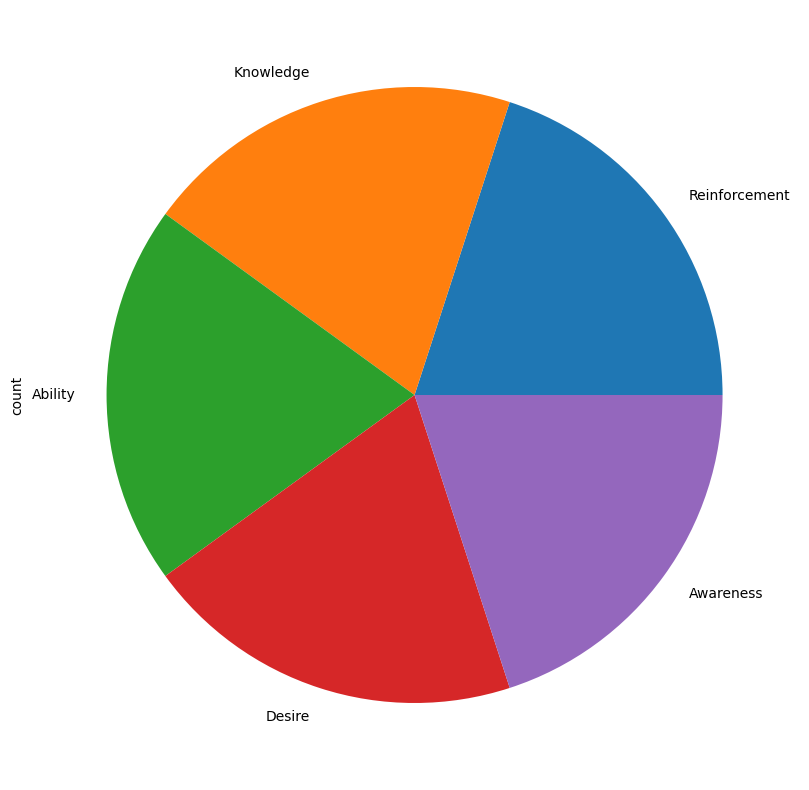

In [23]:
df.Category.value_counts().plot(kind='pie', figsize=(10,10))

In [24]:
num_labels = 5  # Set this to the number of classes in your classification task
NUM_LABELS = 5

In [25]:
# to clear gpu memory
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [26]:
# DistilBert base
from transformers import DistilBertForSequenceClassification
from transformers import DistilBertTokenizer

# Initialize the model with the correct number of label
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=num_labels)

# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')


C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\huggingface_hub\file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_transform.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequence

In [27]:
# Bert base
from transformers import BertForSequenceClassification, BertTokenizerFast
# Load pre-trained DistilBERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=NUM_LABELS)

# Load pre-trained DistilBERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly i

In [28]:
# RoBERTa large
from transformers import RobertaForSequenceClassification, RobertaTokenizer

# Load pre-trained RoBERTa large model for sequence classification
model = RobertaForSequenceClassification.from_pretrained('roberta-large', num_labels=NUM_LABELS)

# Load pre-trained RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-large')


Some weights of the model checkpoint at roberta-large were not used when initializing RobertaForSequenceClassification: ['lm_head.dense.weight', 'lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias']
You should 

In [29]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
device

'cuda'

In [30]:
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
 

In [31]:
SIZE= df.shape[0]

pivot = int(len(df)*3/4)

train_texts= list(df.Response[:pivot])

val_texts=   list(df.Response[pivot:])

train_labels= list(df.labels[:pivot])

val_labels=   list(df.labels[pivot: ])

In [32]:
len(train_texts)

75

In [33]:
len(train_texts), len(val_texts)

(75, 25)

In [34]:
train_texts

['Recognizing the impact on student engagement, I’m committed to maintaining these strategies.',
 'Through extensive reading, I now understand the importance of fostering soft skills in my students.',
 'New educational practices have been successfully merged with my existing teaching methods.',
 'Understanding the new assessment tools, I feel confident in applying them to measure student progress.',
 'I’ve researched industry trends extensively, and I’m prepared to integrate this knowledge into my lectures.',
 'My commitment to staying relevant as an educator is what drives my continuous improvement efforts.',
 'I’ve always wanted to create an environment where every student feels included, and now I’m determined to make it happen.',
 'The positive feedback from students has reinforced the value of these new teaching methods.',
 'The realization hit when I saw the gap between what we teach and what employers expect.',
 'The moment I noticed the decline in student engagement, I knew som

In [35]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings  = tokenizer(val_texts, truncation=True, padding=True)


In [36]:
train_encodings

{'input_ids': [[0, 21109, 18857, 2787, 5, 913, 15, 1294, 4921, 6, 38, 17, 27, 119, 2021, 7, 6780, 209, 4964, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 23803, 4935, 2600, 6, 38, 122, 1346, 5, 3585, 9, 26242, 3793, 2417, 11, 127, 521, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 4030, 5984, 3464, 33, 57, 5116, 21379, 19, 127, 2210, 5307, 6448, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 44188, 5, 92, 4990, 3270, 6, 38, 619, 3230, 11, 9889, 106, 7, 2450, 1294, 2017, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 100, 17, 27, 548, 27285, 539, 3926, 18808, 6, 8, 38, 17, 27, 119, 2460, 7, 13997, 42, 2655, 88, 127, 25798, 4, 2, 1, 1, 1, 1, 1], [0, 2387, 2720, 7, 4959, 4249, 25, 41, 23356, 16, 99, 6790, 127, 11152, 3855, 1170, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 100, 17, 27, 548, 460, 770, 7, 1045, 41, 1737, 147, 358, 1294, 2653, 1165, 6, 8, 122, 38, 17, 27, 119, 3030, 7, 146, 24, 1369, 4, 2], [0, 133, 1313, 6456, 31, 521, 34, 19816, 5, 923, 9, 209, 92, 5307, 6448, 4, 2, 1, 1, 1

In [37]:
from torch.utils.data import DataLoader as TorchDataLoader, Dataset
import torch

class DataLoader(Dataset):
   
    
    def __init__(self, encodings, labels):
       
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        
        # Retrieve tokenized data for the given index
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Add the label for the given index to the item dictionary
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        
        return len(self.labels)


In [38]:
train_dataloader = DataLoader(train_encodings, train_labels)

val_dataloader = DataLoader(val_encodings, val_labels)

In [39]:
train_dataloader[10]

{'input_ids': tensor([    0, 31842, 17601,   154,    15,  1294,  7762,     6,    38,  6238,
             5, 14195,     9, 12432,   154,    84,  7484,    19,   595,   539,
           782,     4,     2,     1,     1,     1,     1,     1,     1,     1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
         0, 0, 0, 0, 0, 0]),
 'labels': tensor(0)}

In [40]:
from transformers import TrainingArguments, Trainer

In [41]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    """
    Computes accuracy, F1, precision, and recall for a given set of predictions.
    
    Args:
        pred (obj): An object containing label_ids and predictions attributes.
            - label_ids (array-like): A 1D array of true class labels.
            - predictions (array-like): A 2D array where each row represents
              an observation, and each column represents the probability of 
              that observation belonging to a certain class.
              
    Returns:
        dict: A dictionary containing the following metrics:
            - Accuracy (float): The proportion of correctly classified instances.
            - F1 (float): The macro F1 score, which is the harmonic mean of precision
              and recall. Macro averaging calculates the metric independently for
              each class and then takes the average.
            - Precision (float): The macro precision, which is the number of true
              positives divided by the sum of true positives and false positives.
            - Recall (float): The macro recall, which is the number of true positives
              divided by the sum of true positives and false negatives.
    """
    # Extract true labels from the input object
    labels = pred.label_ids
    
    # Obtain predicted class labels by finding the column index with the maximum probability
    preds = pred.predictions.argmax(-1)
    
    # Compute macro precision, recall, and F1 score using sklearn's precision_recall_fscore_support function
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    
    # Calculate the accuracy score using sklearn's accuracy_score function
    acc = accuracy_score(labels, preds)
    
    # Return the computed metrics as a dictionary
    return {
        'Accuracy': acc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    }

In [42]:
training_args = TrainingArguments(
    # The output directory where the model predictions and checkpoints will be written
    output_dir='./TTC4900Model', 
    do_train=True,
    do_eval=True,
    #  The number of epochs, defaults to 3.0 
    num_train_epochs=50,              
    per_device_train_batch_size=5,  
    per_device_eval_batch_size=5,
    learning_rate=1e-5,
    # Number of steps used for a linear warmup
    warmup_steps=500,                
    weight_decay=0.01,
    logging_strategy='steps',
   # TensorBoard log directory                 
    logging_dir='./multi-class-logs',            
    logging_steps=10,
    evaluation_strategy="steps",
    eval_steps=10,
    save_strategy="steps", 
    fp16=True,
    load_best_model_at_end=True
)

In [43]:
trainer = Trainer(
    # the pre-trained model that will be fine-tuned 
    model=model,
     # training arguments that we defined above                        
    args=training_args,                 
    train_dataset=train_dataloader,         
    eval_dataset=val_dataloader,            
    compute_metrics= compute_metrics
)

Using cuda_amp half precision backend
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:593: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [44]:
trainer.train()

C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 75
  Num Epochs = 50
  Instantaneous batch size per device = 5
  Total train batch size (w. parallel, distributed & accumulation) = 5
  Gradient Accumulation steps = 1
  Total optimization steps = 750
  Number of trainable parameters = 355364869
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:2504: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
10,1.645500,1.649844,0.200000,0.066667,0.040000,0.200000
20,1.709000,1.647890,0.200000,0.066667,0.040000,0.200000
30,1.634300,1.643945,0.200000,0.066667,0.040000,0.200000
40,1.683400,1.635547,0.200000,0.066667,0.040000,0.200000
50,1.637400,1.623047,0.200000,0.066667,0.040000,0.200000
60,1.572900,1.598750,0.360000,0.333099,0.337143,0.393333
70,1.646600,1.595820,0.320000,0.251948,0.194444,0.380000
80,1.468700,1.619883,0.200000,0.120574,0.090110,0.183333
90,1.560000,1.627227,0.280000,0.177255,0.135043,0.283333
100,1.485100,1.603477,0.280000,0.169118,0.116667,0.310000


***** Running Evaluation *****
  Num examples = 25
  Batch size = 5
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:2504: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)
***** Running Evaluation *****
  Num examples = 25
  Batch size = 5
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` param

TrainOutput(global_step=750, training_loss=0.4355370919633036, metrics={'train_runtime': 1652.2673, 'train_samples_per_second': 2.27, 'train_steps_per_second': 0.454, 'total_flos': 204772150575000.0, 'train_loss': 0.4355370919633036, 'epoch': 50.0})

In [45]:
q=[trainer.evaluate(eval_dataset=df_org) for df_org in [train_dataloader, val_dataloader]]

pd.DataFrame(q, index=["train","val"]).iloc[:,:5]

***** Running Evaluation *****
  Num examples = 75
  Batch size = 5
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:2504: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)


***** Running Evaluation *****
  Num examples = 25
  Batch size = 5
C:\Users\ritvi\miniconda3\envs\EMP_env\lib\site-packages\transformers\trainer.py:2504: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  else torch.cuda.amp.autocast(cache_enabled=cache_enabled, dtype=self.amp_dtype)


,eval_loss,eval_Accuracy,eval_F1,eval_Precision,eval_Recall
train,0.000259,1.0,1.0,1.0,1.0
val,0.007807,1.0,1.0,1.0,1.0


In [46]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
def predict(text):
    """
    Predicts the class label for a given input text

    Args:
        text (str): The input text for which the class label needs to be predicted.

    Returns:
        probs (torch.Tensor): Class probabilities for the input text.
        pred_label_idx (torch.Tensor): The index of the predicted class label.
        pred_label (str): The predicted class label.
    """
    # Tokenize the input text and move tensors to the GPU if available
    inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to("cuda")

    # Get model output (logits)
    outputs = model(**inputs)

    probs = outputs[0].softmax(1)
    """ Explanation outputs: The BERT model returns a tuple containing the output logits (and possibly other elements depending on the model configuration). In this case, the output logits are the first element in the tuple, which is why we access it using outputs[0].

    outputs[0]: This is a tensor containing the raw output logits for each class. The shape of the tensor is (batch_size, num_classes) where batch_size is the number of input samples (in this case, 1, as we are predicting for a single input text) and num_classes is the number of target classes.

    softmax(1): The softmax function is applied along dimension 1 (the class dimension) to convert the raw logits into class probabilities. Softmax normalizes the logits so that they sum to 1, making them interpretable as probabilities. """

    # Get the index of the class with the highest probability
    # argmax() finds the index of the maximum value in the tensor along a specified dimension.
    # By default, if no dimension is specified, it returns the index of the maximum value in the flattened tensor.
    pred_label_idx = probs.argmax()

    # Now map the predicted class index to the actual class label 
    # Since pred_label_idx is a tensor containing a single value (the predicted class index), 
    # the .item() method is used to extract the value as a scalar
    pred_label = model.config.id2label[pred_label_idx.item()]

    return probs, pred_label_idx, pred_label

In [47]:
import pandas as pd
from nltk.tokenize import sent_tokenize
from IPython.core.display import HTML, display

# Define the colors for each type of oppression using hex color codes
colors = {
    'LABEL_0': '#FFFF00',  # yellow, awareness
    'LABEL_1': '#0000FF',  # blue, desire
    'LABEL_2': '#008000',  # green, knowledge
    'LABEL_3': '#FF0000',  # red, ability
    'LABEL_3': '#FFA500',  # Orange, reinforcement
}

def highlight_text(text, predictions):
    """
    Highlights text based on predictions using HTML.

    Args:
        text (str): The text to be highlighted.
        predictions (list of tuples): Each tuple contains (sentence, predicted_label).

    Returns:
        str: HTML string with highlighted text.
    """
    html_text = ""
    sentences = sent_tokenize(text)
    
    for sentence in sentences:
        highlighted = False
        for sent, label in predictions:
            if sent.strip().lower() in sentence.strip().lower():
                color = colors.get(label, '#FFFFFF')  # default to white if no color found
                html_text += f'<span style="background-color: {color};">{sentence}</span> '
                highlighted = True
                break
        if not highlighted:
            html_text += f'{sentence} '
    
    return html_text.strip()


# Process and display each comment
for index, row in M5.iterrows():
    text = row['Syllabus Comments']
    
    # Split text into sentences
    sentences = sent_tokenize(text)
    
    # Predict for each sentence
    predictions = [(sent, predict(sent)[2]) for sent in sentences]  # Assuming predict returns (probs, pred_label_idx, pred_label)
    
    # Generate highlighted HTML
    highlighted_html = highlight_text(text, predictions)
    
    # Display highlighted HTML using IPython
    display(HTML(f"<h3>Comment {index + 1}</h3><p>{highlighted_html}</p>"))


C:\Users\ritvi\AppData\Local\Temp\ipykernel_21432\4105996853.py:3: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import HTML, display


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\ritvi/nltk_data'
    - 'C:\\Users\\ritvi\\miniconda3\\envs\\EMP_env\\nltk_data'
    - 'C:\\Users\\ritvi\\miniconda3\\envs\\EMP_env\\share\\nltk_data'
    - 'C:\\Users\\ritvi\\miniconda3\\envs\\EMP_env\\lib\\nltk_data'
    - 'C:\\Users\\ritvi\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************
